# View SIIM DICOM Sample
This notebook loads the SIIM medical images dataset, lists DICOM files, and displays a sample image.

Matplotlib is building the font cache; this may take a moment.


Dataset path: C:\Users\bhmoh\.cache\kagglehub\datasets\kmader\siim-medical-images\versions\6
DICOM files: 100
Sample: C:\Users\bhmoh\.cache\kagglehub\datasets\kmader\siim-medical-images\versions\6\dicom_dir\ID_0000_AGE_0060_CONTRAST_1_CT.dcm
Modality: CT
Rows x Cols: 512 x 512
Pixel array shape: (512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

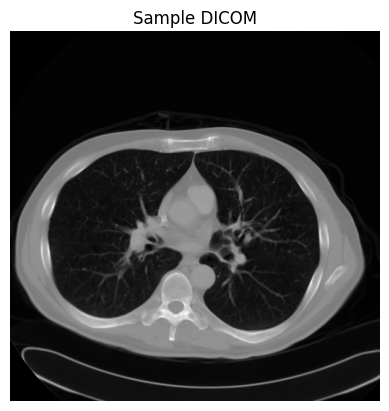

In [3]:
from pathlib import Path
import kagglehub
import numpy as np
import pydicom
import matplotlib.pyplot as plt

dataset_path = Path(kagglehub.dataset_download("kmader/siim-medical-images"))
print("Dataset path:", dataset_path)

dcm_files = sorted(dataset_path.rglob("*.dcm"))
print("DICOM files:", len(dcm_files))

sample_path = dcm_files[0]
ds = pydicom.dcmread(str(sample_path))
pixels = ds.pixel_array

print("Sample:", sample_path)
print("Modality:", getattr(ds, "Modality", "N/A"))
print("Rows x Cols:", getattr(ds, "Rows", "N/A"), "x", getattr(ds, "Columns", "N/A"))
print("Pixel array shape:", pixels.shape)

plt.imshow(pixels, cmap="gray")
plt.title("Sample DICOM")
plt.axis("off")

In [ ]:
pip install torch

^C
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   -- ------------------------------------- 6.0/113.8 MB 30.3 MB/s eta 0:00:04
   ---- ----------------------------------- 12.3/113.8 MB 29.7 MB/s eta 0:00:04
   ------ --------------------------------- 18.6/113.8 MB 29.4 MB/s eta 0:00:04
   -------- ------------------------------- 24.9/113.8 MB 29.4 MB/s eta 0:00:04
   ---------- ----------------------------- 31.2/113.8 MB 29.4 MB/s eta 0:00:03
   ------------- -------------------------- 37.2/113.8 MB 29.3 MB/s eta 0:00:03
   -------------- ------------------------- 42.5/113.8 MB 28.4 MB/s eta 0:00:03
   ----------------- ---------------------- 49.3/113.8 MB 28.8 MB/s eta 0:00:03
   ------------------

In [1]:
# ROI extraction: ViT patch embeddings + k-means clustering
# If timm/torch/sklearn are unavailable, install them first.
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn.functional as F
    import timm
    from sklearn.cluster import KMeans
    _vit_ok = True
except Exception as e:
    _vit_ok = False
    print("Missing deps for ViT ROI extraction:", e)


def _normalize_image(img):
    img = img.astype(np.float32)
    img -= img.min()
    if img.max() > 0:
        img /= img.max()
    return img


def _get_patch_embeddings(img_norm, model_name="vit_base_patch16_224"):
    # img_norm: HxW in [0, 1]
    h, w = img_norm.shape
    # ViT expects 224x224 and 3 channels
    img_t = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0)
    img_t = F.interpolate(img_t, size=(224, 224), mode="bilinear", align_corners=False)
    img_t = img_t.repeat(1, 3, 1, 1)

    model = timm.create_model(model_name, pretrained=True, num_classes=0, global_pool="")
    model.eval()
    with torch.no_grad():
        # forward_features returns tokens including class token
        feats = model.forward_features(img_t)

    # Remove class token if present
    if feats.ndim == 3 and feats.shape[1] > 1:
        feats = feats[:, 1:, :]

    # Reshape to patch grid
    num_patches = feats.shape[1]
    grid = int(np.sqrt(num_patches))
    feats = feats.reshape(1, grid, grid, -1)
    return feats.squeeze(0).cpu().numpy()


def _cluster_roi(patch_feats, img_norm, k=2):
    h, w = img_norm.shape
    ph, pw, d = patch_feats.shape
    feats_flat = patch_feats.reshape(-1, d)

    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(feats_flat).reshape(ph, pw)

    # Map patch labels to image space
    scale_y = h // ph
    scale_x = w // pw
    mask = np.kron(labels, np.ones((scale_y, scale_x), dtype=np.int32))
    mask = mask[:h, :w]

    # Choose ROI cluster: higher mean intensity in original image
    mean0 = img_norm[mask == 0].mean() if np.any(mask == 0) else -1
    mean1 = img_norm[mask == 1].mean() if np.any(mask == 1) else -1
    roi_label = 0 if mean0 >= mean1 else 1
    roi = (mask == roi_label).astype(np.uint8)

    # Optional post-processing
    try:
        from scipy.ndimage import binary_closing, binary_fill_holes
        roi = binary_closing(roi, iterations=2)
        roi = binary_fill_holes(roi)
        roi = roi.astype(np.uint8)
    except Exception:
        pass

    return roi


# Run ROI extraction on the loaded sample
img_norm = _normalize_image(pixels)

if _vit_ok:
    patch_feats = _get_patch_embeddings(img_norm)
    roi_mask = _cluster_roi(patch_feats, img_norm)

    # Visualize
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_norm, cmap="gray")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_norm, cmap="gray")
    plt.imshow(roi_mask, alpha=0.35, cmap="jet")
    plt.title("ROI Mask (Unsupervised)")
    plt.axis("off")
else:
    print("ROI extraction skipped. Install torch, timm, scikit-learn.")


Missing deps for ViT ROI extraction: No module named 'torch'


NameError: name 'pixels' is not defined